# **Stacked Model For Deployment**

----
## Summary

This notebook builds a **stacked ensemble model** to predict ICU patient risk (`bad_outcome`) using a fully cleaned and feature-engineered dataset.

### Purpose
The goal of this model is to serve as a **supporting (second-opinion) model** in our deployment system. It prioritizes:
- Balanced performance (precision + recall)
- Generalizability to new data
- Simplicity for deployment (Streamlit-ready)

### Approach
- Used an **80/20 train-test split** with **Stratified K-Fold (OOF stacking)** on the training set
- Combined multiple base models:
  - Random Forest
  - XGBoost
  - CatBoost
  - Logistic Regression
  - SVM
- Trained a **meta-model (Logistic Regression)** on out-of-fold predictions
- Performed **threshold tuning** to balance precision, recall, and F1 score
- Built a **deployment-ready pipeline** that handles preprocessing → prediction → classification

### Key Decisions
- **Removed SMOTE** to improve generalization and reduce false positives
- **No calibration** to keep deployment simple and stable
- Designed as a **single callable model object** for easy integration into Streamlit

### Results (Test Set)
- ROC AUC: ~0.85
- Precision (class 1): ~0.56
- Recall (class 1): ~0.74
- F1 Score: ~0.64

### Outcome
The final model is:
- **Stable and well-balanced**
- **Deployment-ready**
- Suitable as a **clinical decision-supporting “second opinion” model**

------

In [1]:
# imports
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from dataclasses import dataclass

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, classification_report,
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    roc_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.calibration import calibration_curve

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
import shap

In [2]:
# load in data
df = pd.read_csv("cleaned_feature_engineered_v1.csv")

target_col = "bad_outcome"

drop_cols = [target_col]
for col in ["patientunitstayid"]:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(columns=drop_cols)
y = df[target_col]

print("Dataset shape:", df.shape)
print("Target rate:", y.mean())
print("Categorical columns:", X.select_dtypes(include=["object", "category"]).columns.tolist())

Dataset shape: (2520, 73)
Target rate: 0.23095238095238096
Categorical columns: ['gender', 'ethnicity', 'unittype', 'numbedscategory', 'teachingstatus', 'region']


/var/folders/x4/884p4sk97gs4f8n6js6qwc1h0000gn/T/ipykernel_28325/2431772865.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Categorical columns:", X.select_dtypes(include=["object", "category"]).columns.tolist())


### train/test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target rate:", y_train.mean())
print("Test target rate:", y_test.mean())

Train shape: (2016, 72)
Test shape: (504, 72)
Train target rate: 0.23115079365079366
Test target rate: 0.23015873015873015


### preprocessing

In [9]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

# num cols
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# cat cols
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

### base models

In [12]:
USE_SMOTE = False # trying without SMOTE first

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

base_models = {
    "rf": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced",
        random_state=42
    ),

    "xgb": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        scale_pos_weight=pos_weight,
        random_state=42
    ),

    "cat": CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        verbose=0,
        random_seed=42
    ),

    "lr": LogisticRegression(
        max_iter=3000,
        class_weight="balanced"
    ),

    "svm": SVC(
        probability=True,
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        random_state=42
    )
}

meta_model = LogisticRegression(max_iter=1000)

In [14]:
# fit preprocessor on fold-train only, transform fold-train and fold-valid.

def fit_fold_model(preprocessor, model, X_tr, y_tr, X_va, use_smote=False):

    prep = clone(preprocessor)
    mdl = clone(model)

    X_tr_proc = prep.fit_transform(X_tr)
    X_va_proc = prep.transform(X_va)

    if use_smote:
        sm = SMOTE(random_state=42)
        X_tr_proc, y_tr = sm.fit_resample(X_tr_proc, y_tr)

    mdl.fit(X_tr_proc, y_tr)
    va_probs = mdl.predict_proba(X_va_proc)[:, 1]

    return va_probs


# out fold pred probs for ea base model
def get_oof_base_predictions(X, y, preprocessor, base_models, n_splits=5, use_smote=False):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    oof_dict = {
        name: np.zeros(len(X))
        for name in base_models.keys()
    }

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        print(f"Fold {fold}/{n_splits}")

        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr = y.iloc[tr_idx]

        for name, model in base_models.items():
            va_probs = fit_fold_model(
                preprocessor=preprocessor,
                model=model,
                X_tr=X_tr,
                y_tr=y_tr,
                X_va=X_va,
                use_smote=use_smote
            )
            oof_dict[name][va_idx] = va_probs

    return pd.DataFrame(oof_dict, index=X.index)

In [16]:
# OOF meta-features on train only
meta_train = get_oof_base_predictions(
    X=X_train,
    y=y_train,
    preprocessor=preprocessor,
    base_models=base_models,
    n_splits=5,
    use_smote=USE_SMOTE
)

print(meta_train.head())
print("Meta-train shape:", meta_train.shape)

Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
            rf       xgb       cat        lr       svm
922   0.316368  0.141306  0.151045  0.114485  0.127319
947   0.236744  0.229072  0.125404  0.312155  0.123223
2165  0.360504  0.403955  0.222242  0.191174  0.153498
867   0.147473  0.079253  0.050481  0.135503  0.069693
2448  0.411296  0.897969  0.440510  0.610471  0.425477
Meta-train shape: (2016, 5)


In [18]:
# fit meta-model on OOF preds
meta_model.fit(meta_train, y_train)

train_oof_probs = meta_model.predict_proba(meta_train)[:, 1]

print("OOF Train ROC AUC:", roc_auc_score(y_train, train_oof_probs))

OOF Train ROC AUC: 0.8206202408971341


In [20]:
# choose threshold from OOF training probs

thresholds = np.arange(0.10, 0.51, 0.01)

threshold_results = []

for t in thresholds:
    train_oof_preds = (train_oof_probs >= t).astype(int)

    precision = precision_score(y_train, train_oof_preds, zero_division=0)
    recall = recall_score(y_train, train_oof_preds, zero_division=0)
    f1 = f1_score(y_train, train_oof_preds, zero_division=0)

    threshold_results.append({
        "threshold": round(float(t), 2),
        "precision_1": precision,
        "recall_1": recall,
        "f1_1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df["weighted_score"] = (
    0.30 * threshold_df["precision_1"] +
    0.35 * threshold_df["recall_1"] +
    0.35 * threshold_df["f1_1"]
)

threshold_df = threshold_df.sort_values(
    by=["weighted_score", "f1_1", "recall_1", "precision_1"],
    ascending=False
)

print(threshold_df.head(10))

best_threshold = float(threshold_df.iloc[0]["threshold"])
print("Selected threshold:", best_threshold)

    threshold  precision_1  recall_1      f1_1  weighted_score
12       0.22     0.530717  0.667382  0.591255        0.599738
10       0.20     0.503106  0.695279  0.583784        0.598604
11       0.21     0.514563  0.682403  0.586716        0.598561
13       0.23     0.538324  0.648069  0.588121        0.594164
8        0.18     0.470014  0.723176  0.569738        0.593524
15       0.25     0.564453  0.620172  0.591002        0.593247
9        0.19     0.487332  0.701717  0.575198        0.593120
16       0.26     0.572289  0.611588  0.591286        0.592693
14       0.24     0.549348  0.633047  0.588235        0.592253
17       0.27     0.584034  0.596567  0.590234        0.590590
Selected threshold: 0.22


In [22]:
# fit final preprocessor on full training set

fitted_preprocessor = clone(preprocessor)

X_train_proc = fitted_preprocessor.fit_transform(X_train)
X_test_proc = fitted_preprocessor.transform(X_test)

if USE_SMOTE:
    sm = SMOTE(random_state=42)
    X_train_proc_fit, y_train_fit = sm.fit_resample(X_train_proc, y_train)
else:
    X_train_proc_fit, y_train_fit = X_train_proc, y_train

fitted_base_models = {}

for name, model in base_models.items():
    mdl = clone(model)
    mdl.fit(X_train_proc_fit, y_train_fit)
    fitted_base_models[name] = mdl

print("base models fitted.")

base models fitted.


### build test meta-features and final test prob

In [25]:
meta_test = pd.DataFrame({
    name: mdl.predict_proba(X_test_proc)[:, 1]
    for name, mdl in fitted_base_models.items()
})

test_probs = meta_model.predict_proba(meta_test)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)

print("Final Test ROC AUC:", roc_auc_score(y_test, test_probs))
print("\nFinal Test Report:\n")
print(classification_report(y_test, test_preds, digits=3))

Final Test ROC AUC: 0.8548924635620334

Final Test Report:

              precision    recall  f1-score   support

           0      0.914     0.825     0.867       388
           1      0.558     0.741     0.637       116

    accuracy                          0.806       504
   macro avg      0.736     0.783     0.752       504
weighted avg      0.832     0.806     0.814       504



Test ROC AUC: 0.8548924635620334
Test Average Precision: 0.7112446495861507
Test Precision: 0.5584415584415584
Test Recall: 0.7413793103448276
Test F1: 0.6370370370370371


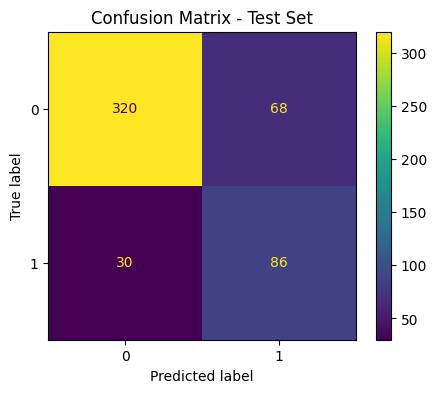

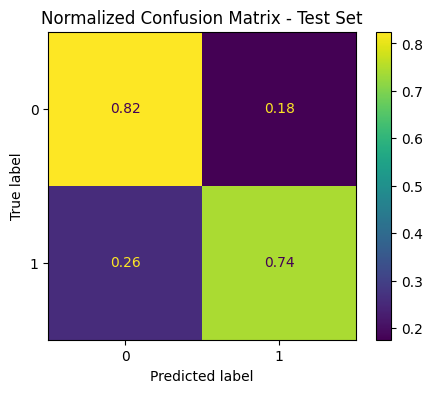

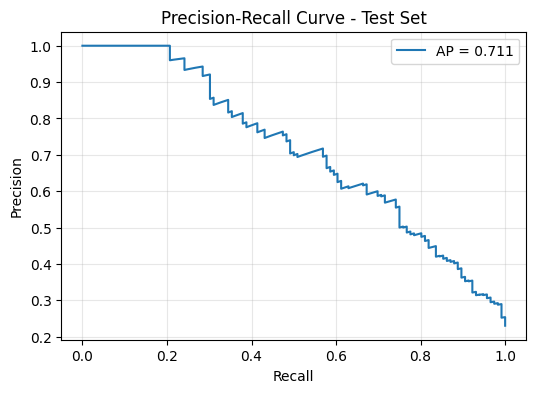

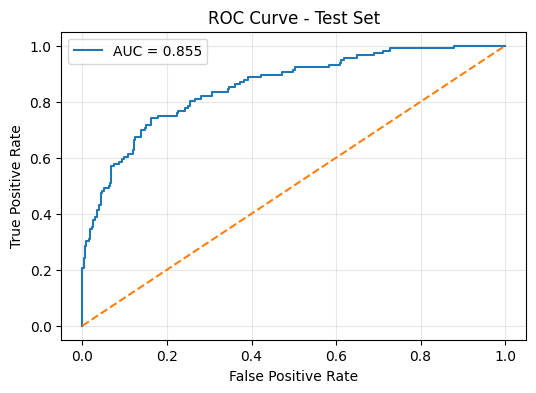

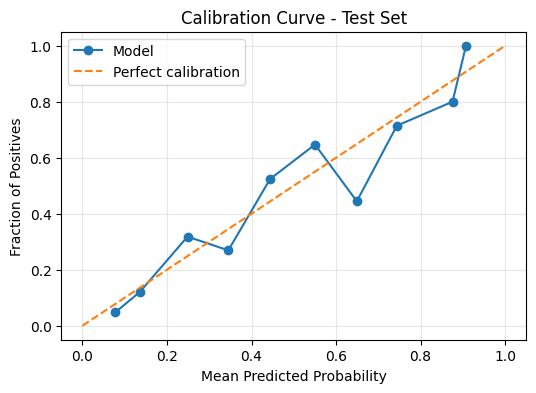

In [27]:
print("Test ROC AUC:", roc_auc_score(y_test, test_probs))
print("Test Average Precision:", average_precision_score(y_test, test_probs))
print("Test Precision:", precision_score(y_test, test_preds, zero_division=0))
print("Test Recall:", recall_score(y_test, test_preds, zero_division=0))
print("Test F1:", f1_score(y_test, test_preds, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix - Test Set")
plt.show()

# Normalized confusion matrix
cm_norm = confusion_matrix(y_test, test_preds, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, values_format=".2f")
plt.title("Normalized Confusion Matrix - Test Set")
plt.show()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, test_probs)
ap_score = average_precision_score(y_test, test_probs)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f"AP = {ap_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Test Set")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calibration curve for final raw probabilities
prob_true, prob_pred = calibration_curve(y_test, test_probs, n_bins=10, strategy="uniform")

plt.figure(figsize=(6, 4))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve - Test Set")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

-----------------------------------
### deployment-ready object

In [30]:
@dataclass
class StackedDeploymentModel:
    preprocessor: object
    base_models: dict
    meta_model: object
    threshold: float
    feature_columns: list

    def _prepare_input(self, X):
        if isinstance(X, dict):
            X = pd.DataFrame([X])

        X = X.copy()

        for col in self.feature_columns:
            if col not in X.columns:
                X[col] = np.nan

        X = X[self.feature_columns]
        return X

    def predict_proba(self, X):
        X = self._prepare_input(X)
        X_proc = self.preprocessor.transform(X)

        meta_features = pd.DataFrame({
            name: model.predict_proba(X_proc)[:, 1]
            for name, model in self.base_models.items()
        })

        probs = self.meta_model.predict_proba(meta_features)[:, 1]
        return probs

    def predict(self, X):
        probs = self.predict_proba(X)
        return (probs >= self.threshold).astype(int)

In [32]:
import os
# create folder
os.makedirs("artifacts", exist_ok=True)

# build deployment object
deploy_model = StackedDeploymentModel(
    preprocessor=fitted_preprocessor,
    base_models=fitted_base_models,
    meta_model=meta_model,
    threshold=best_threshold,
    feature_columns=X_train.columns.tolist()
)

# save model
joblib.dump(deploy_model, "artifacts/stacked_deploy_model.joblib")

# save meta data
joblib.dump(best_threshold, "artifacts/selected_threshold.joblib")
joblib.dump(X_train.columns.tolist(), "artifacts/feature_columns.joblib")

# save threshold log 
threshold_df.to_csv("artifacts/threshold_results.csv", index=False)

In [34]:
def predict_single_patient(input_dict):
    import joblib
    
    model = joblib.load("artifacts/stacked_deploy_model.joblib")

    prob = model.predict_proba(input_dict)[0]
    pred = model.predict(input_dict)[0]

    return {
        "predicted_probability": float(prob),
        "risk_percent": float(prob * 100),
        "predicted_class": int(pred),
        "threshold_used": float(model.threshold)
    }

In [36]:
sample = X_test.iloc[0].to_dict()
predict_single_patient(sample)

{'predicted_probability': 0.11540058684186556,
 'risk_percent': 11.540058684186556,
 'predicted_class': 0,
 'threshold_used': 0.22}